# Final Results Overview

Display-only notebook for the saved project figures and CSV results, organized by Part 1, Part 2, and Part 3.


## Experiments Summary

This notebook summarizes how Dogs vs Cats classifiers behave when image tiles are kept in order, rearranged at fixed difficulty levels, or analyzed by permutation-hardness metrics.

### Part 1: Model Robustness To Fixed Tile Permutations

- **Permutation functions:** easy, medium, and hard are deterministic tile-order presets with increasing disruption.
  - **Easy:** a small number of nearby tile swaps; most local image structure remains recognizable.
  - **Medium:** more swaps plus row/column shifts; both local continuity and global layout are partially disrupted.
  - **Hard:** many longer-distance swaps, stronger shifts, and global reversal; spatial structure is heavily scrambled.
- **Grid sizes:** 1x1 baseline/no permutation, then 4x4, 7x7, and 10x10 tile grids.
- **Models:** three architecture families were compared.
  - **ResNet-18:** convolutional CNN baseline, chosen for strong local-pattern bias and common image-classification use.
  - **DeiT-Tiny:** compact vision transformer, chosen to test a self-attention model with weaker built-in locality assumptions.
  - **MLP-Mixer:** token/channel mixing MLP architecture, chosen as a non-convolutional, non-attention comparison point.
- **Training/evaluation:** each model ran for 10 epochs over every grid size and permutation condition; results report final and best validation accuracy.

### Part 2: ResNet-18 Improvement Ablations

- **Goal:** test whether targeted training changes improve ResNet-18 robustness relative to the matched Part 1 grid baseline.
- **Experiments:**
  - **Patch shuffle:** randomly shuffles patches during training so the model sees extra tile-order noise beyond the fixed validation permutation.
  - **Regular augmentations:** applies standard image augmentations such as rotation and color jitter to test whether generic augmentation helps.
  - **Mixed original/permuted training:** mixes clean and permuted samples so the model keeps access to natural layout while learning corrupted layouts.
  - **ResNet-18 MLP head:** replaces the linear classifier head with a small MLP head to test whether extra head capacity helps under permutation.
  - **Corruption-probability curriculum:** gradually increases the probability of applying tile permutation during training.
  - **Permutation-difficulty curriculum:** starts from original/easier layouts and moves toward the target grid/permutation difficulty.
- **Training/evaluation:** non-curriculum ablations ran for 10 epochs per grid and permutation; curriculum runs used 30 epochs because 10 epochs was not enough for useful saved results. The plotted metric is best validation accuracy delta from the matched Part 1 baseline.

### Part 3: Tile-Permutation Hardness Analysis

- **Goal:** measure how disruptive each tile permutation is without using model predictions, then compare those scores with ResNet-18 validation accuracy.
- **Hardness metrics:**
  - **Adjacency destruction:** measures how many original neighboring tile relationships are broken.
  - **Global tile displacement:** measures the normalized Manhattan distance tiles move from their original positions.
  - **Spatial permutation entropy:** measures how diverse and spread out tile movement directions/distances are.
  - **Combined hardness:** weighted summary of adjacency destruction, spatial entropy, and global displacement.
- **Evaluation:** each metric is analyzed across the fixed permutation functions and grid sizes, then related to best validation accuracy.


## Preparations


In [56]:
from pathlib import Path
import importlib
import sys

PROJECT_ROOT = next(
    candidate
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (candidate / "src" / "utils" / "results_overview.py").exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.utils.results_overview as results_overview

results_overview = importlib.reload(results_overview)
PROJECT_ROOT = results_overview.find_project_root(PROJECT_ROOT)
PATHS = results_overview.overview_paths(PROJECT_ROOT)
RESULTS_DIR = PATHS["results_dir"]
FIGURES_DIR = PATHS["figures_dir"]
INTERMEDIATE_FIGURES_DIR = PATHS["intermediate_figures_dir"]

PROJECT_ROOT


PosixPath('/Users/royrubin/Documents/GitHub/MLDS_Final_Project')

## Part 1

This section shows the model-family comparison experiments. The plots compare validation accuracy across regular images and fixed tile-permutation grids for ResNet-18, DeiT-Tiny, and MLP-Mixer.

- **Experiments:** fixed tile-permutation grid sweep over baseline/no-permutation and 4x4, 7x7, and 10x10 grids.
- **Models:** ResNet-18, DeiT-Tiny, and MLP-Mixer are compared as the three architecture families.
- **Metrics:** final and best validation accuracy are summarized by grid size to show how tile order affects classification.


### Latest Intermediate Graphs


#### Part 1: Accuracy Vs Tiles DeiT Tiny

`outputs/figures/intermediate/part1_accuracy_vs_tiles_deit_tiny.png`

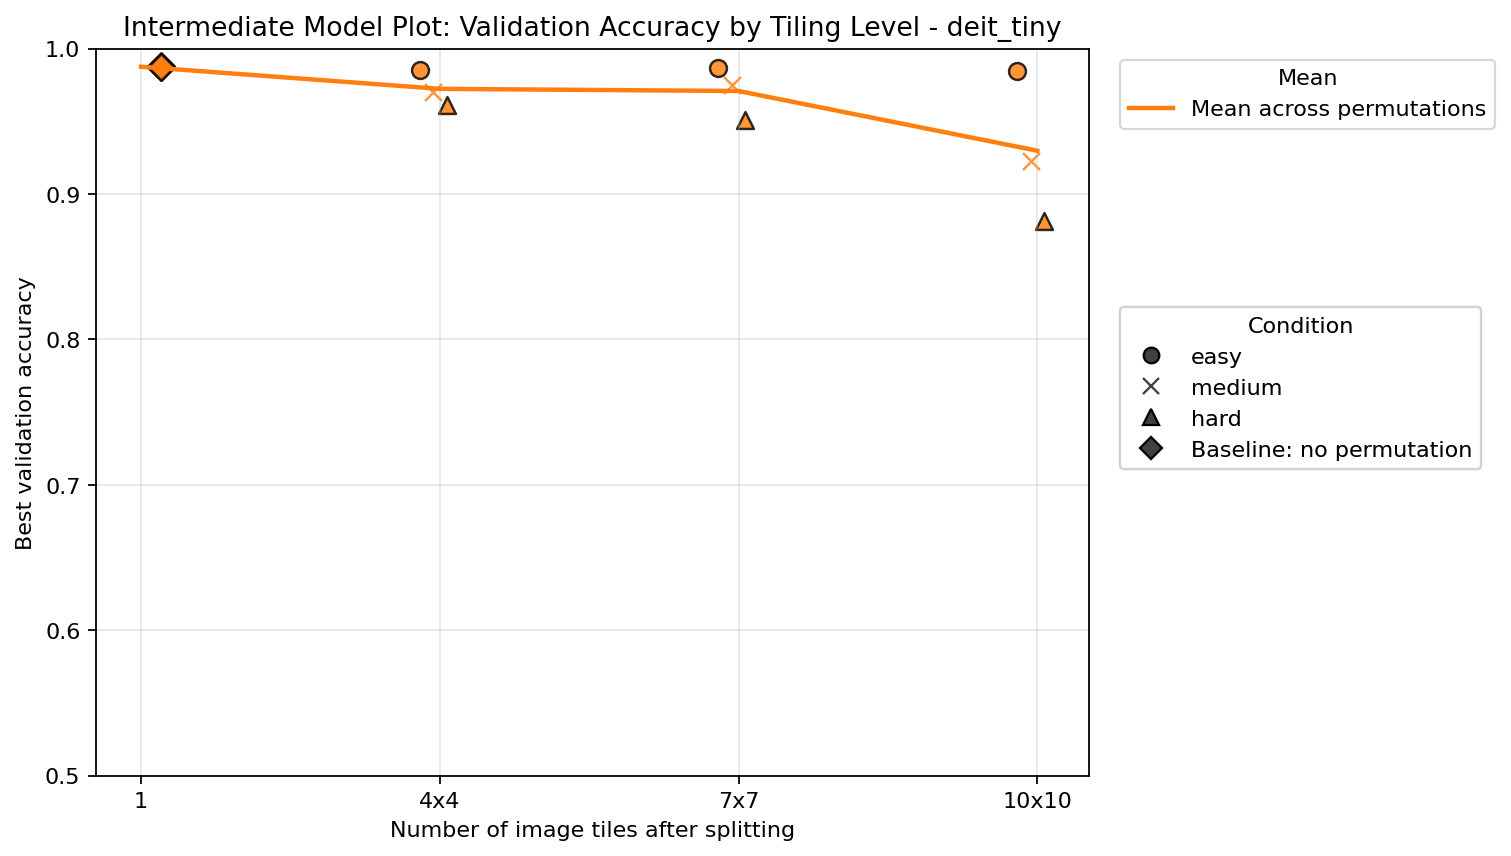

#### Part 1: Accuracy Vs Tiles MLP Mixer Base

`outputs/figures/intermediate/part1_accuracy_vs_tiles_mlp_mixer_base.png`

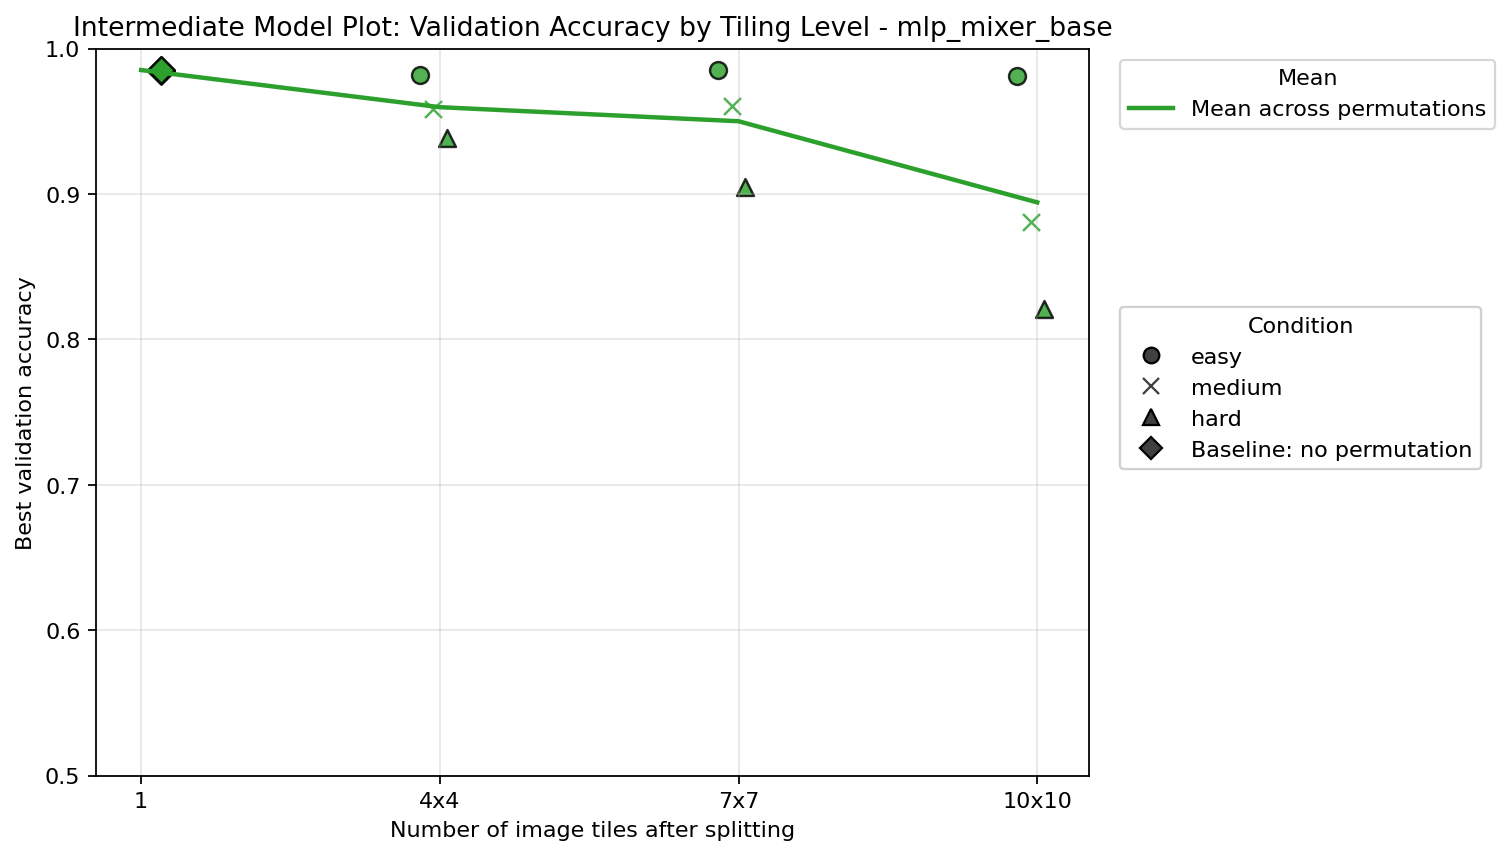

#### Part 1: Accuracy Vs Tiles ResNet-18

`outputs/figures/intermediate/part1_accuracy_vs_tiles_resnet18.png`

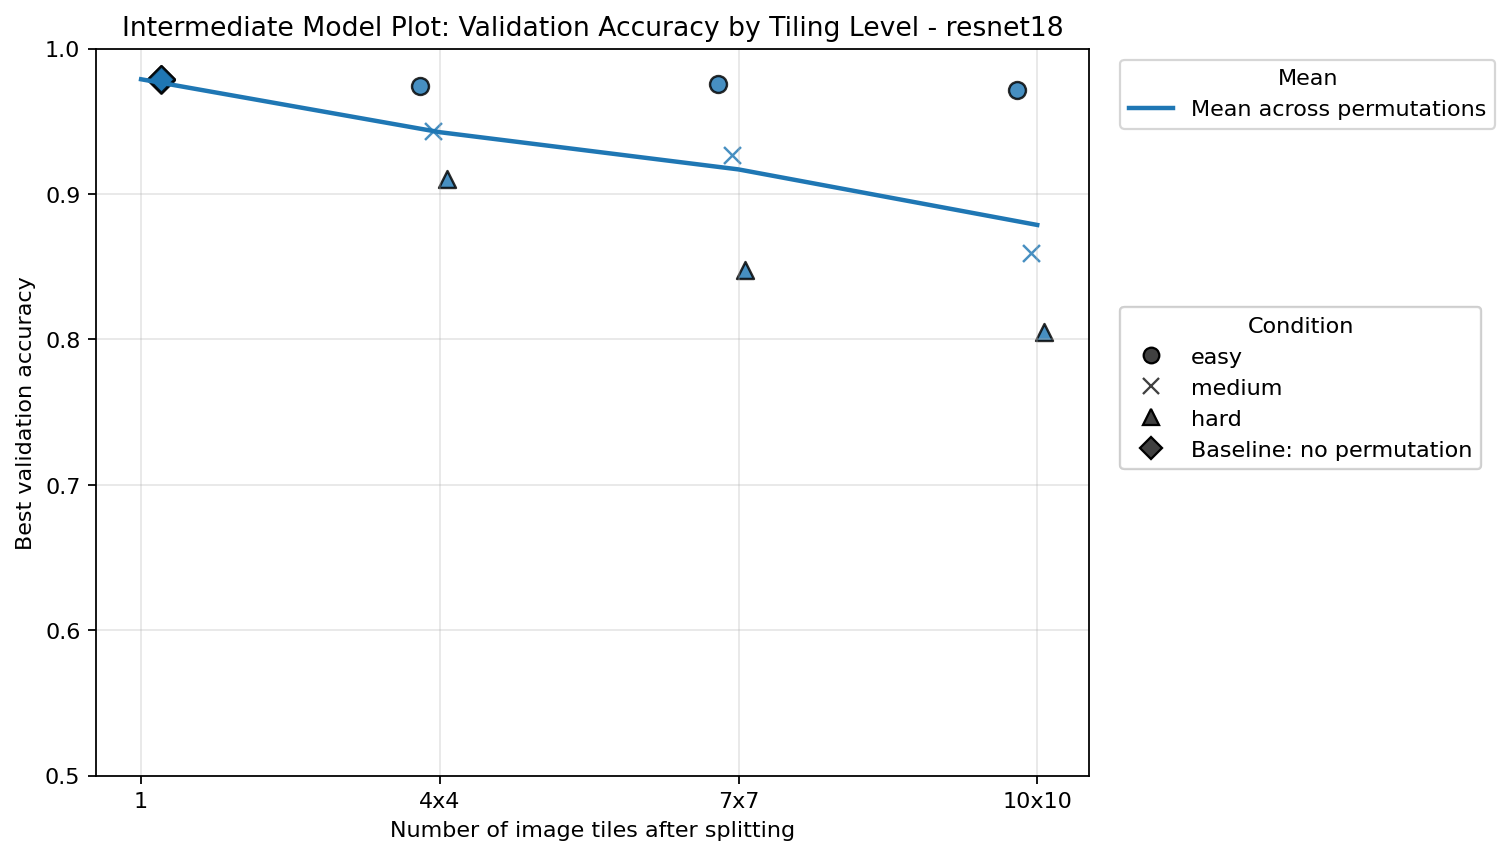

In [57]:
results_overview.show_images(
    results_overview.latest_intermediate_figures(INTERMEDIATE_FIGURES_DIR, "part1_"),
    project_root=PROJECT_ROOT,
)


### Final Graph


#### Part 1: Accuracy Vs Tiles

`outputs/figures/part1_accuracy_vs_tiles.png`

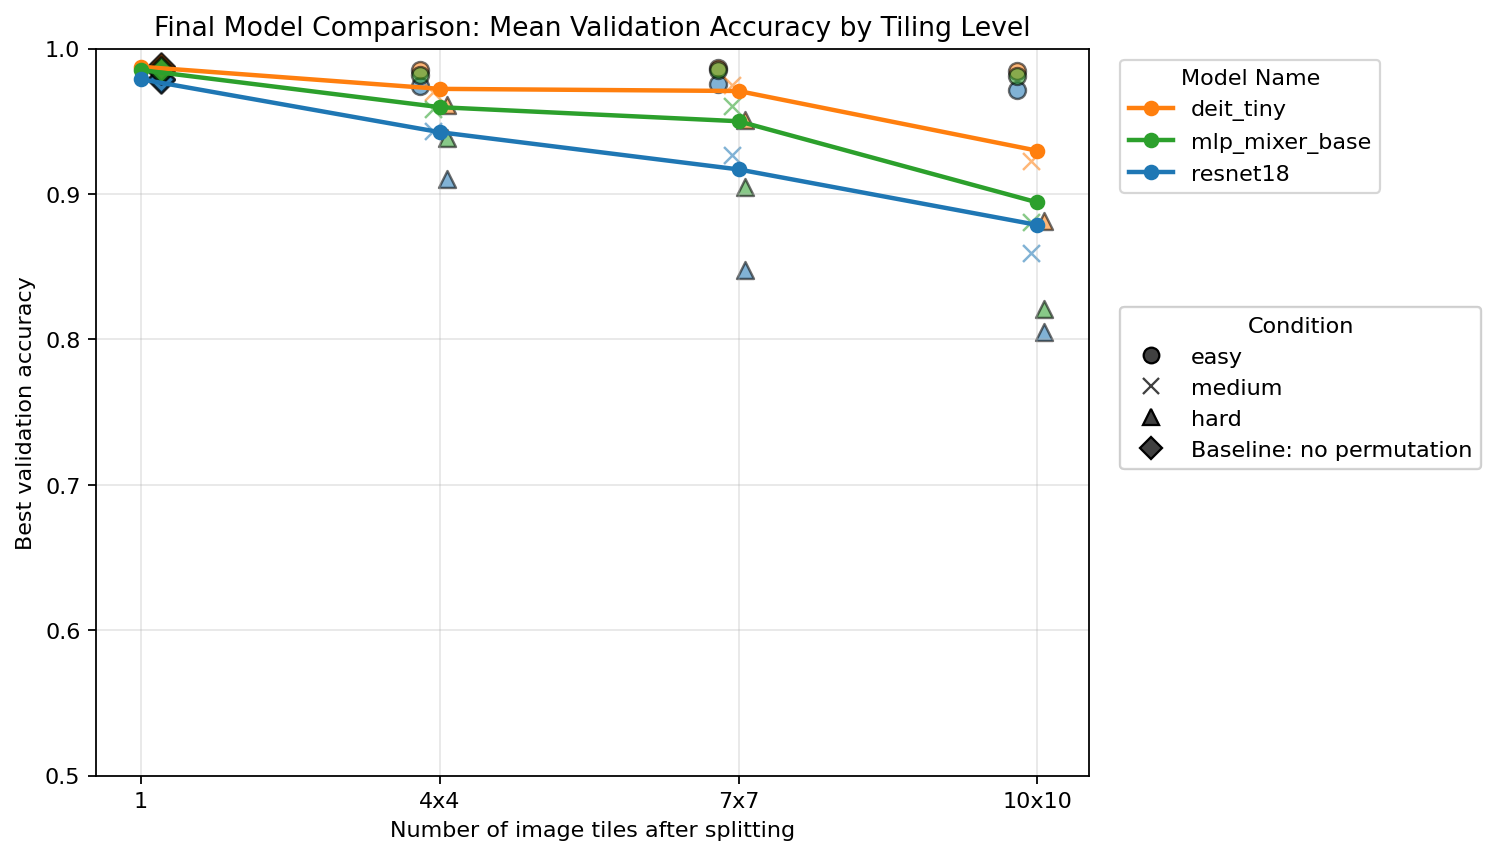

In [58]:
results_overview.show_image(FIGURES_DIR / "part1_accuracy_vs_tiles.png", project_root=PROJECT_ROOT)


## Part 2

This section shows the ResNet-18 improvement ablations. The experiments compare regular augmentations, patch shuffle, mixed original/permuted training, curriculum variants, and the MLP-head ablation against the matched Part 1 baseline.

- **Experiments:** patch shuffle, regular augmentations, mixed original/permuted training, ResNet-18 MLP head, corruption-probability curriculum, and permutation-difficulty curriculum.
- **Models:** ResNet-18 is the shared backbone so each ablation is compared under the same architecture.
- **Metrics:** best validation accuracy delta versus the matched Part 1 grid baseline shows the gain or loss from each ablation.


In [59]:
from src.evaluation.experiment_results import refresh_part2_ablation_comparison_figure

refresh_paths = refresh_part2_ablation_comparison_figure(
    results_dir=str(RESULTS_DIR),
    figures_dir=str(FIGURES_DIR),
)
refresh_paths


{'figure': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/figures/part2_ablation_comparison.png',
 'original_figure': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/figures/part2_ablation_comparison_original_20260601_224446.png',
 'aggregated_results': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results/part2_aggregated_results.csv',
 'raw_results': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results/part2_raw_results.csv'}

### Latest Intermediate Graphs


#### Part 2: Ablation Augmentation Patch Shuffle

`outputs/figures/intermediate/part2_ablation_augmentation_patch_shuffle.png`

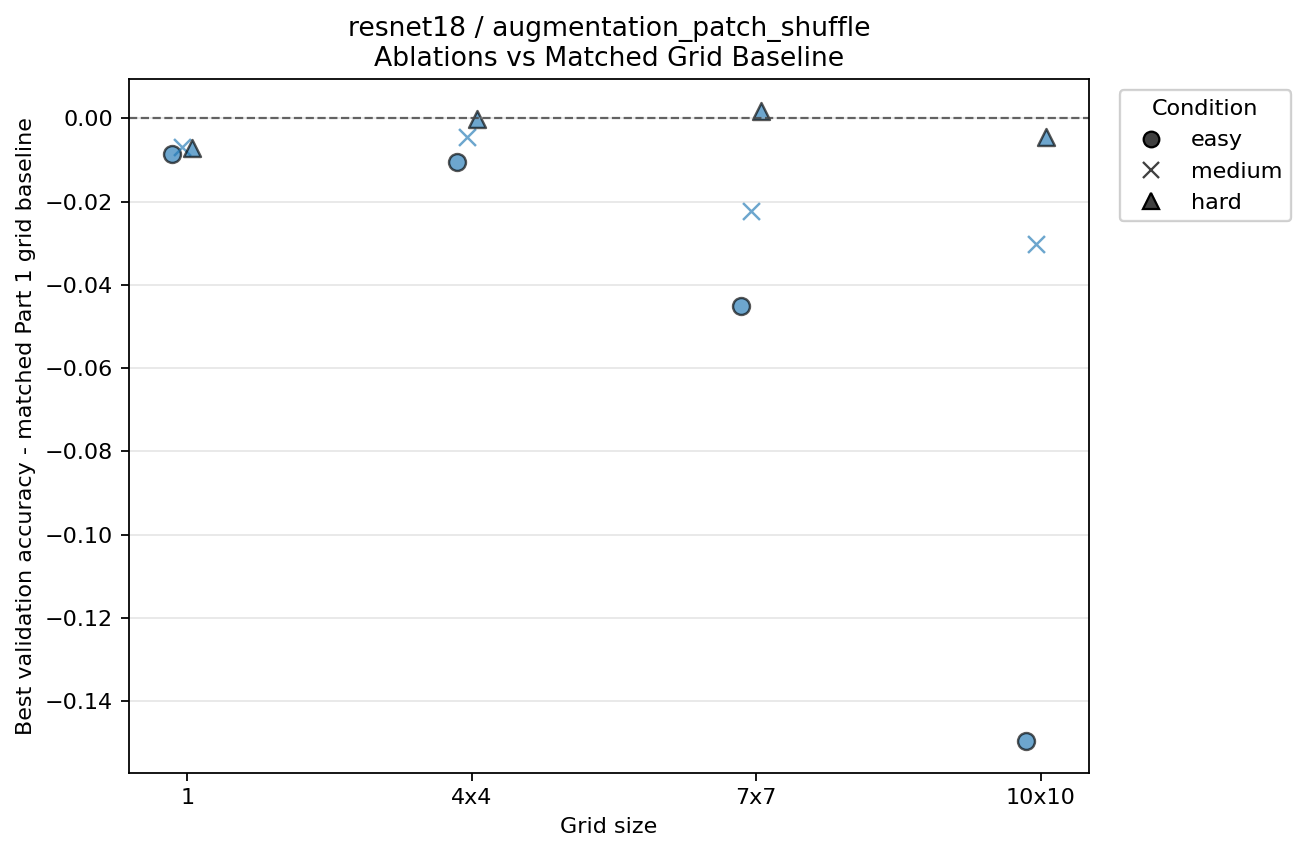

#### Part 2: Ablation Curriculum Corruption Probability

`outputs/figures/intermediate/part2_ablation_curriculum_corruption_probability.png`

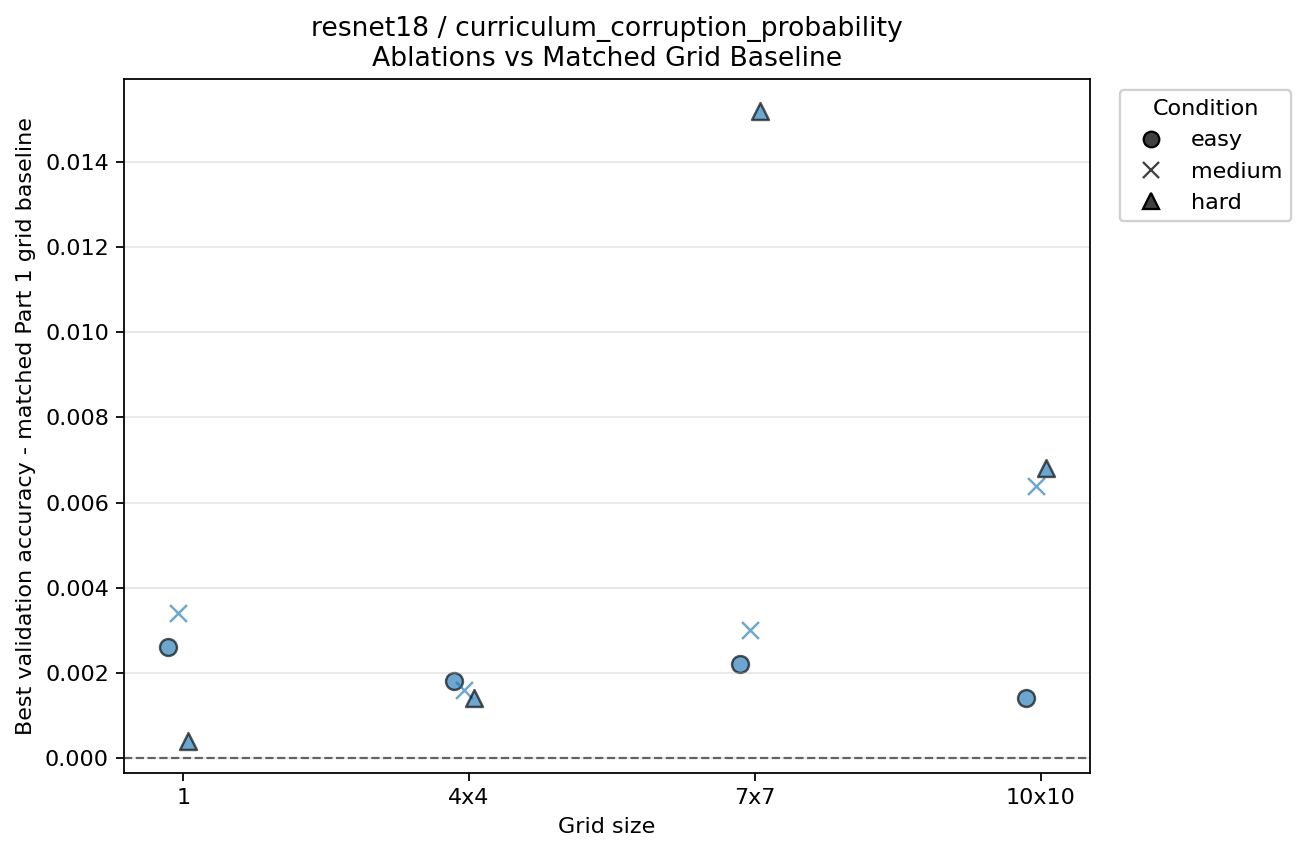

#### Part 2: Ablation Curriculum Permutation Difficulty

`outputs/figures/intermediate/part2_ablation_curriculum_permutation_difficulty.png`

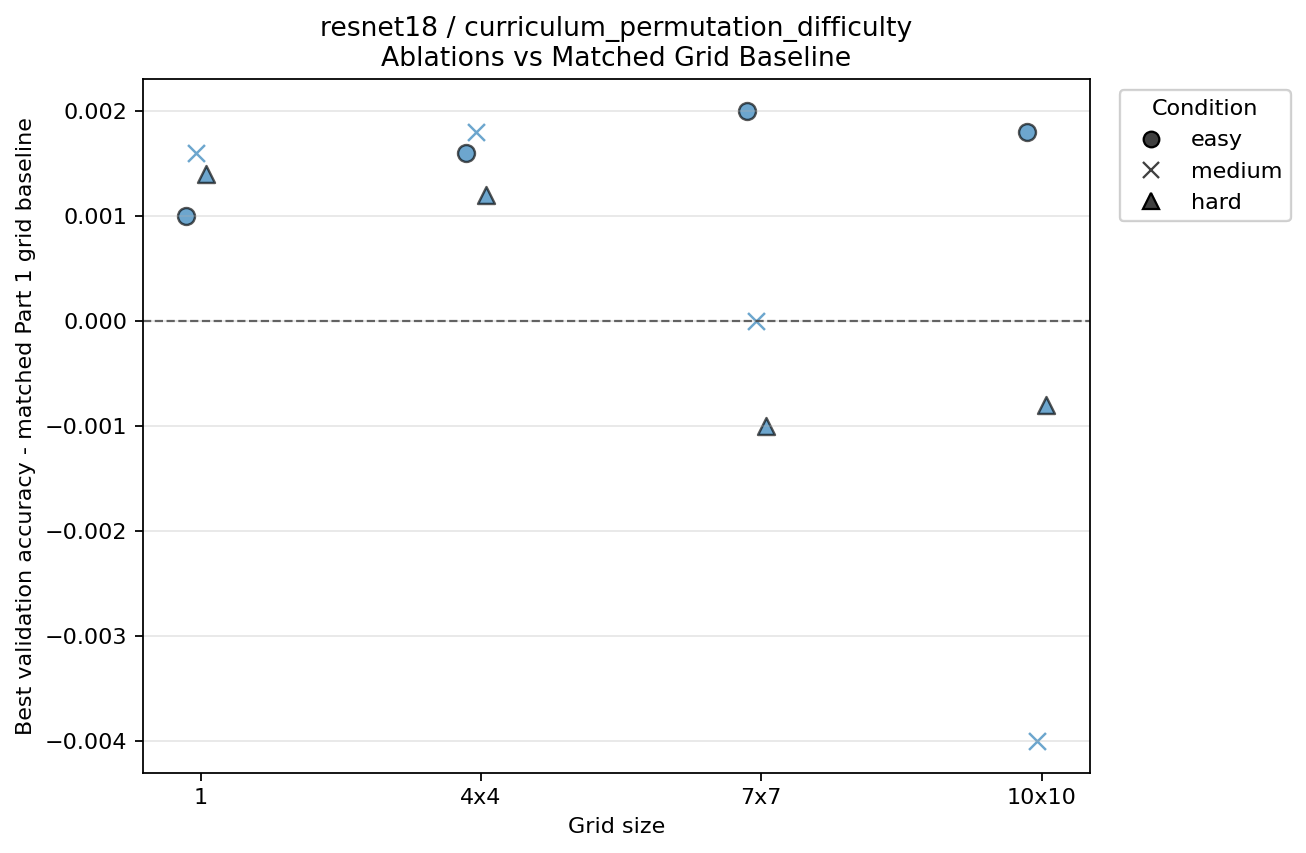

#### Part 2: Ablation Mixed Original Permuted

`outputs/figures/intermediate/part2_ablation_mixed_original_permuted.png`

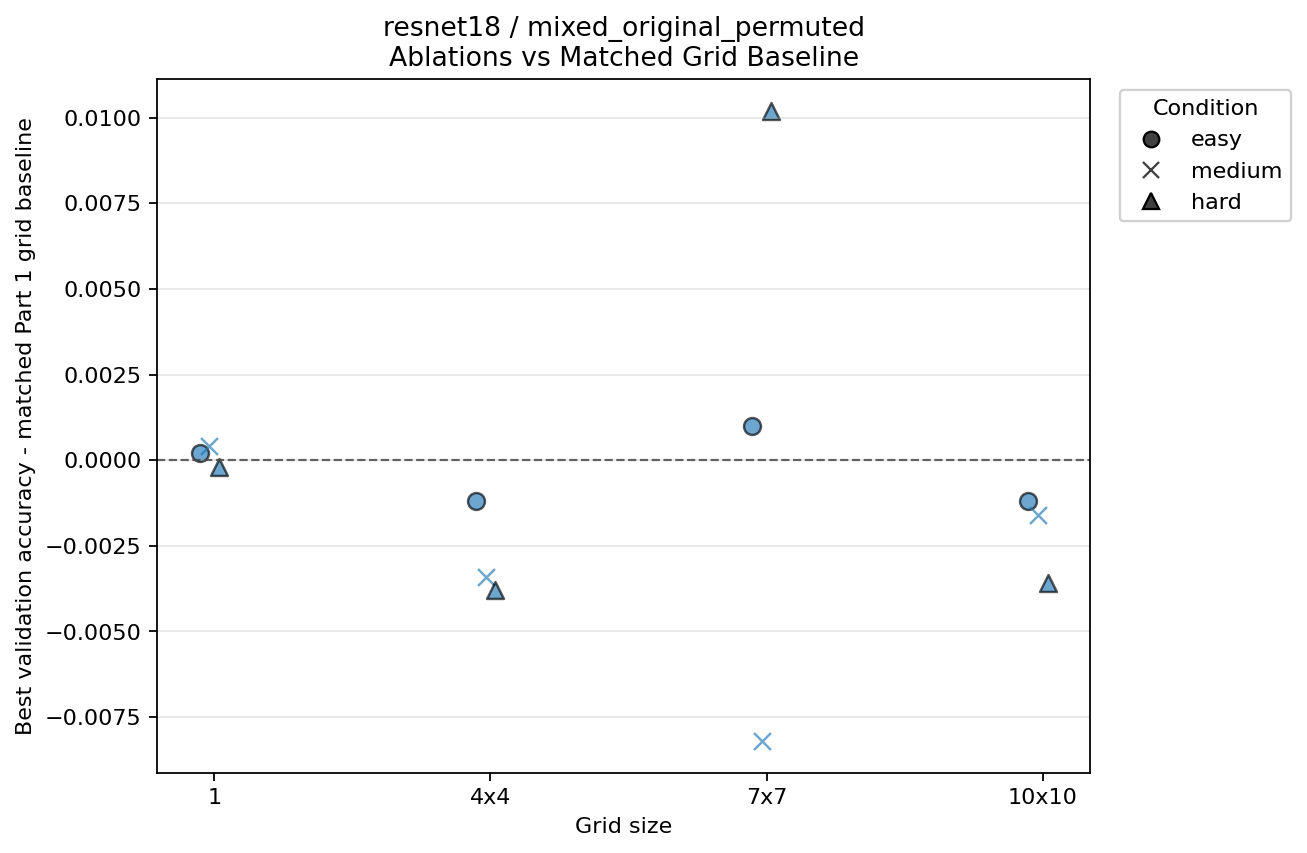

#### Part 2: Ablation Regular Augmentations

`outputs/figures/intermediate/part2_ablation_regular_augmentations.png`

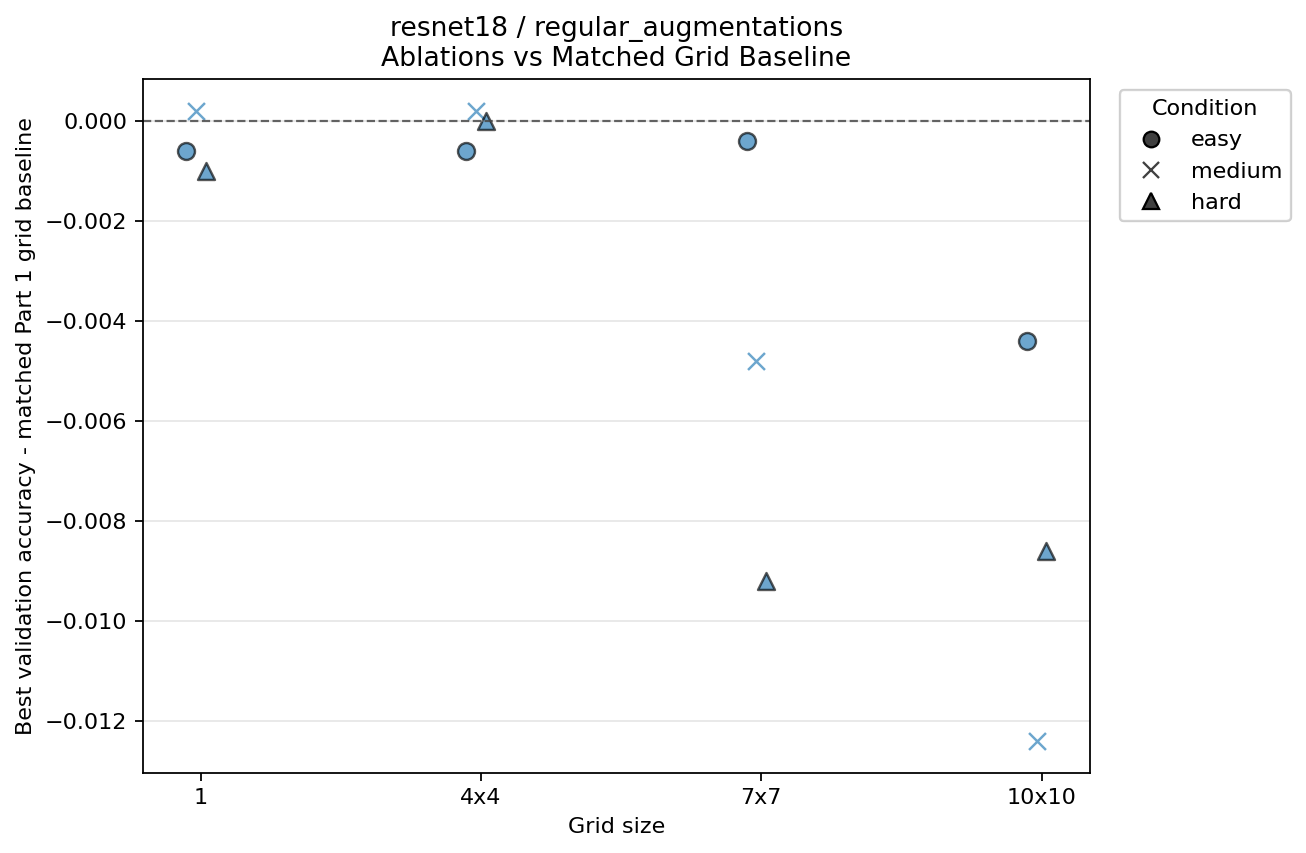

#### Part 2: Ablation ResNet-18 MLP Head

`outputs/figures/intermediate/part2_ablation_resnet18_mlp_head.png`

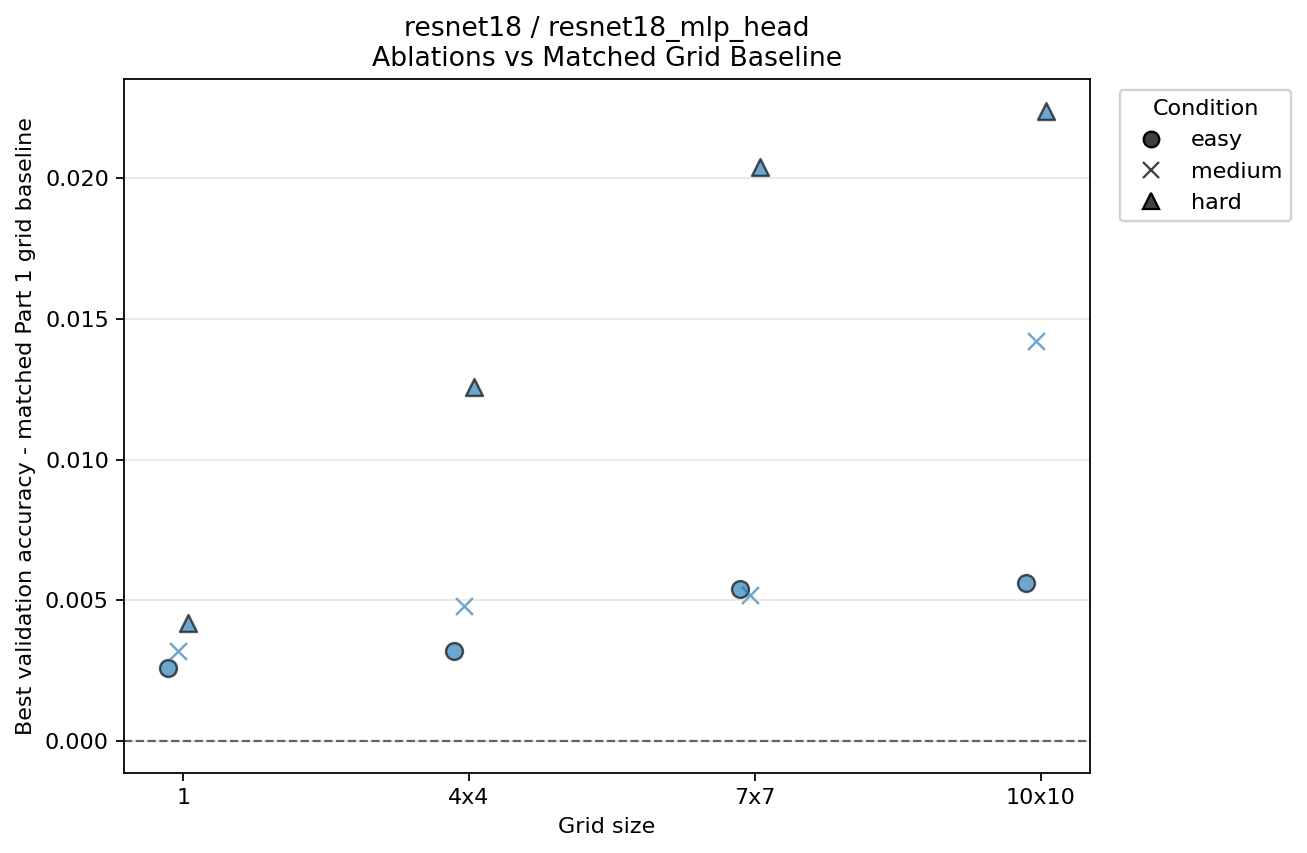

In [60]:
results_overview.show_images(
    results_overview.latest_intermediate_figures(INTERMEDIATE_FIGURES_DIR, "part2_"),
    project_root=PROJECT_ROOT,
)


### Final Graph


#### Part 2: Ablation Comparison

`outputs/figures/part2_ablation_comparison.png`

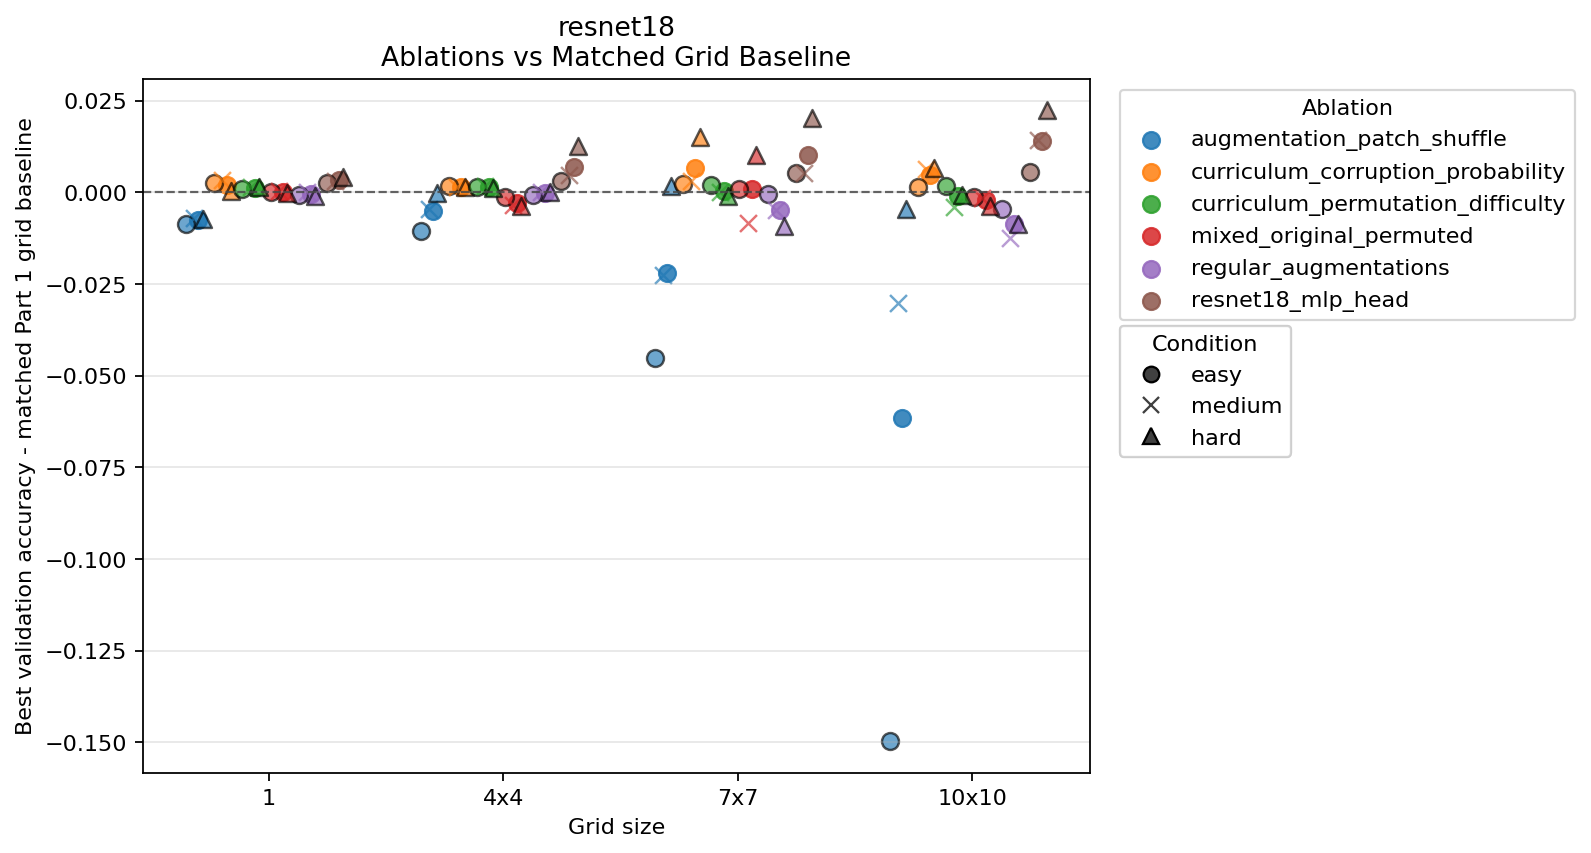

In [61]:
results_overview.show_image(FIGURES_DIR / "part2_ablation_comparison.png", project_root=PROJECT_ROOT)


## Part 3

This section shows tile-permutation hardness analysis for the ResNet-18 runs. It includes the deterministic hardness examples plot, then the saved metric plots relating grid size, hardness scores, and validation accuracy.

- **Experiments:** ResNet-18 tile-permutation hardness analysis reuses the Part 1 grid/permutation conditions.
- **Models:** ResNet-18 is analyzed to connect permutation geometry with the model's validation behavior.
- **Metrics:** adjacency destruction, global tile displacement, spatial permutation entropy, combined hardness, and best validation accuracy.


#### Part 3: Hardness Examples

`outputs/figures/part3_hardness_examples.png`

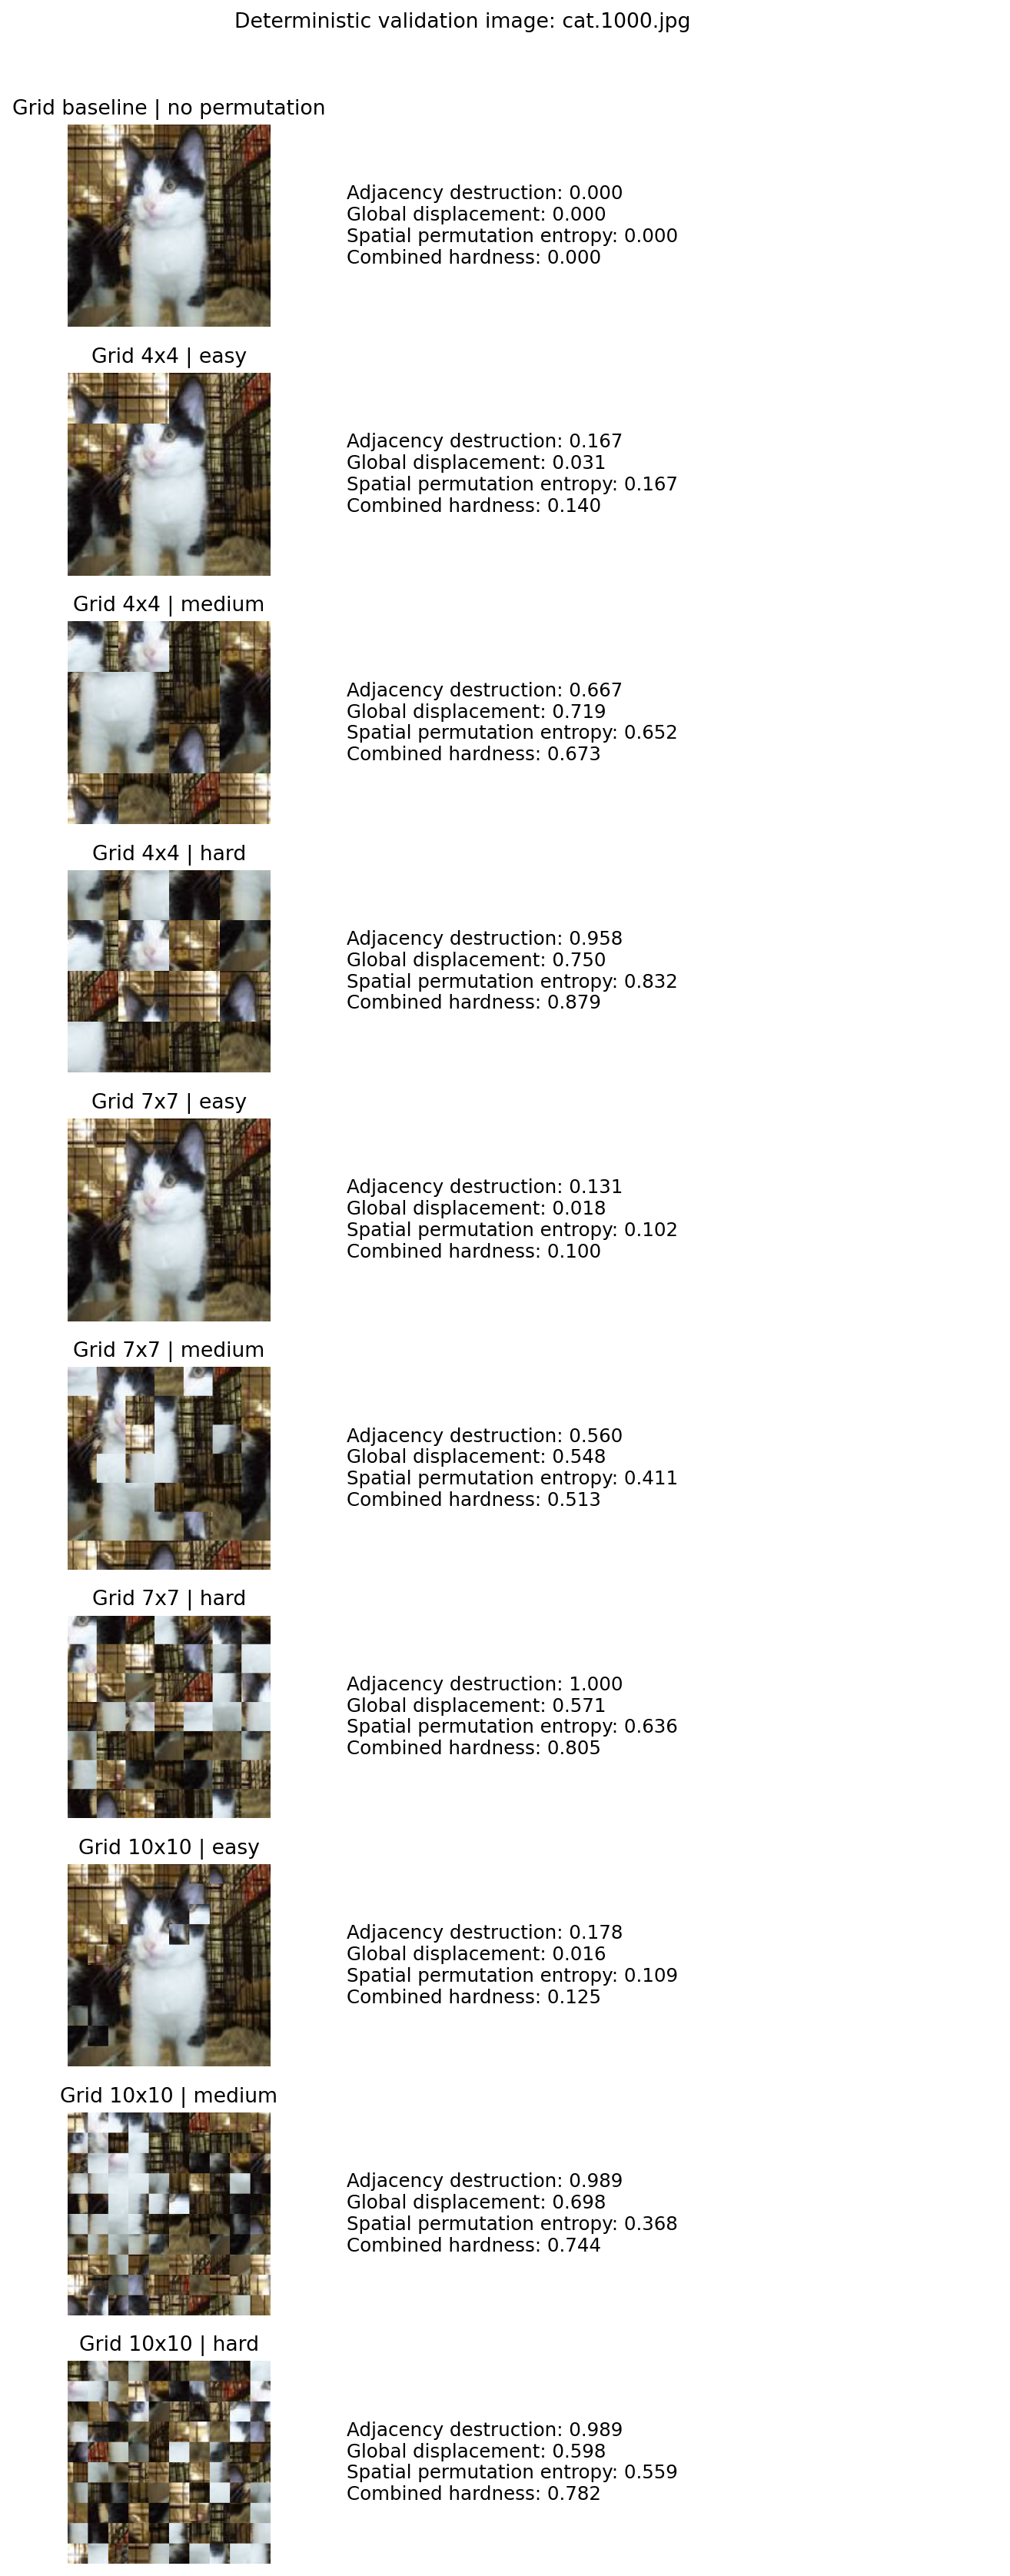

#### Part 3: Adjacency Destruction Hardness Grid Vs Hardness

`outputs/figures/part3_adjacency_destruction_hardness_grid_vs_hardness.png`

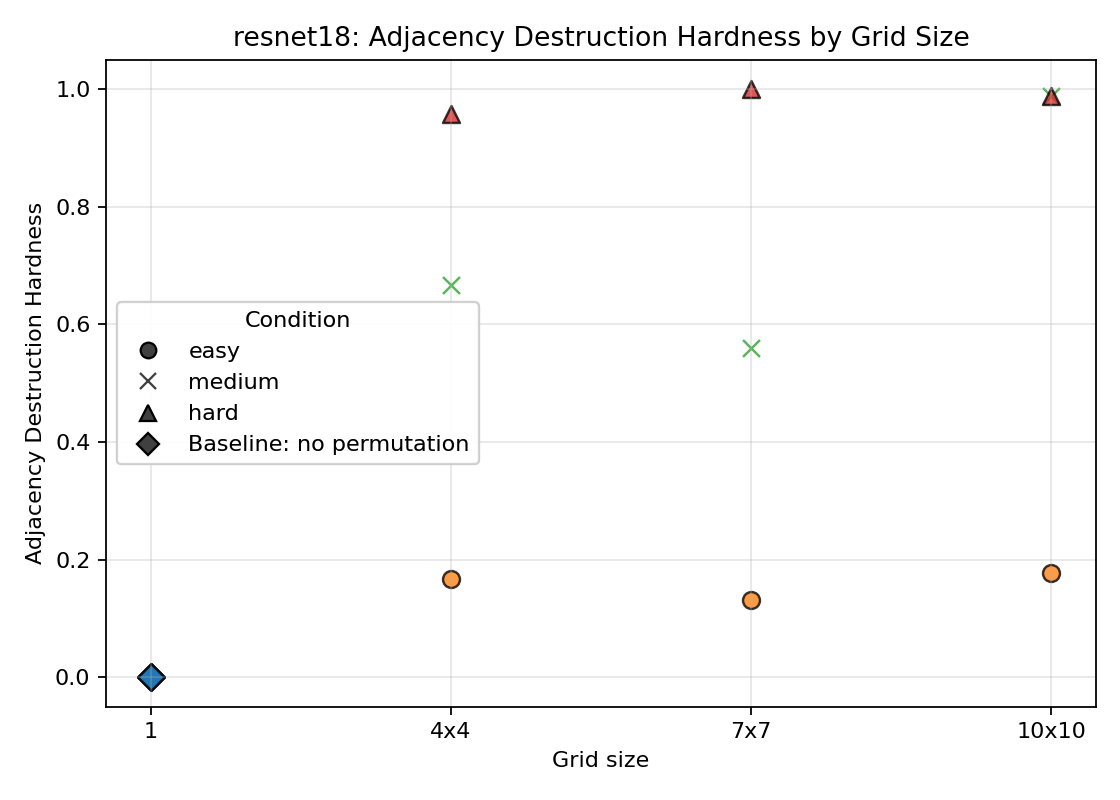

#### Part 3: Combined Hardness Grid Vs Hardness

`outputs/figures/part3_combined_hardness_grid_vs_hardness.png`

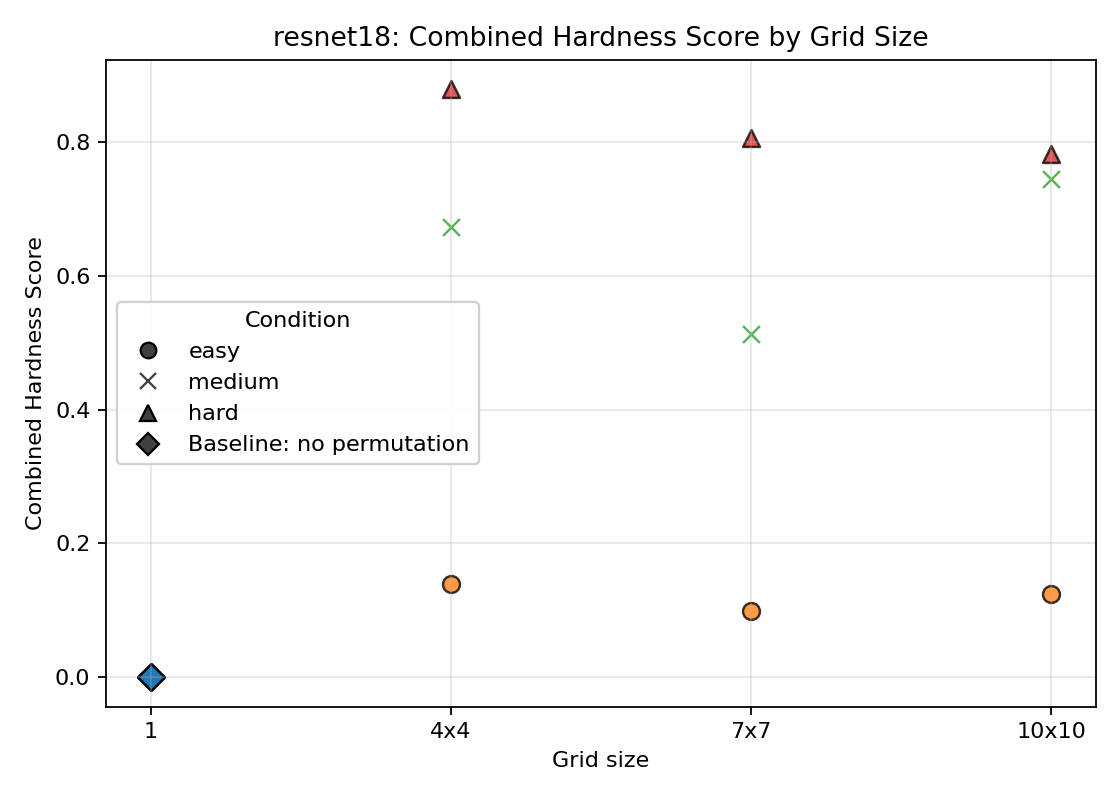

#### Part 3: Global Tile Displacement Grid Vs Hardness

`outputs/figures/part3_global_tile_displacement_grid_vs_hardness.png`

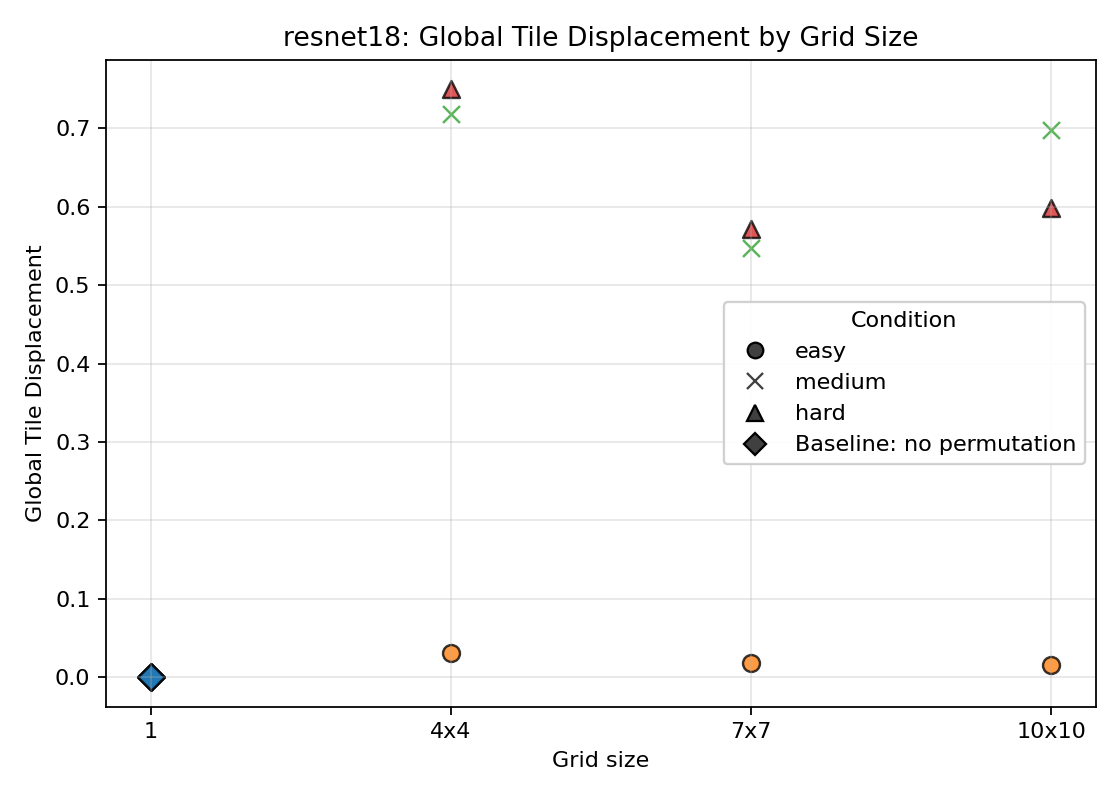

#### Part 3: Spatial Permutation Entropy Grid Vs Hardness

`outputs/figures/part3_spatial_permutation_entropy_grid_vs_hardness.png`

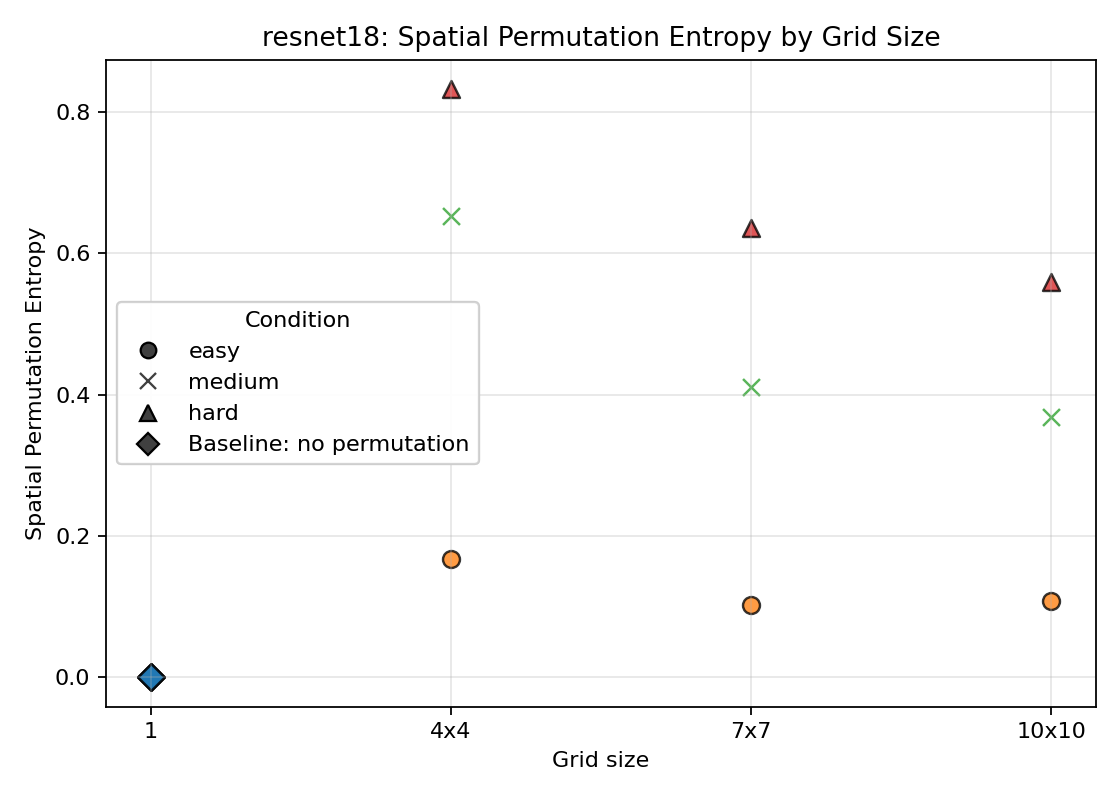

#### Part 3: Adjacency Destruction Hardness Grid Hardness Accuracy 3D

`outputs/figures/part3_adjacency_destruction_hardness_grid_hardness_accuracy_3d.png`

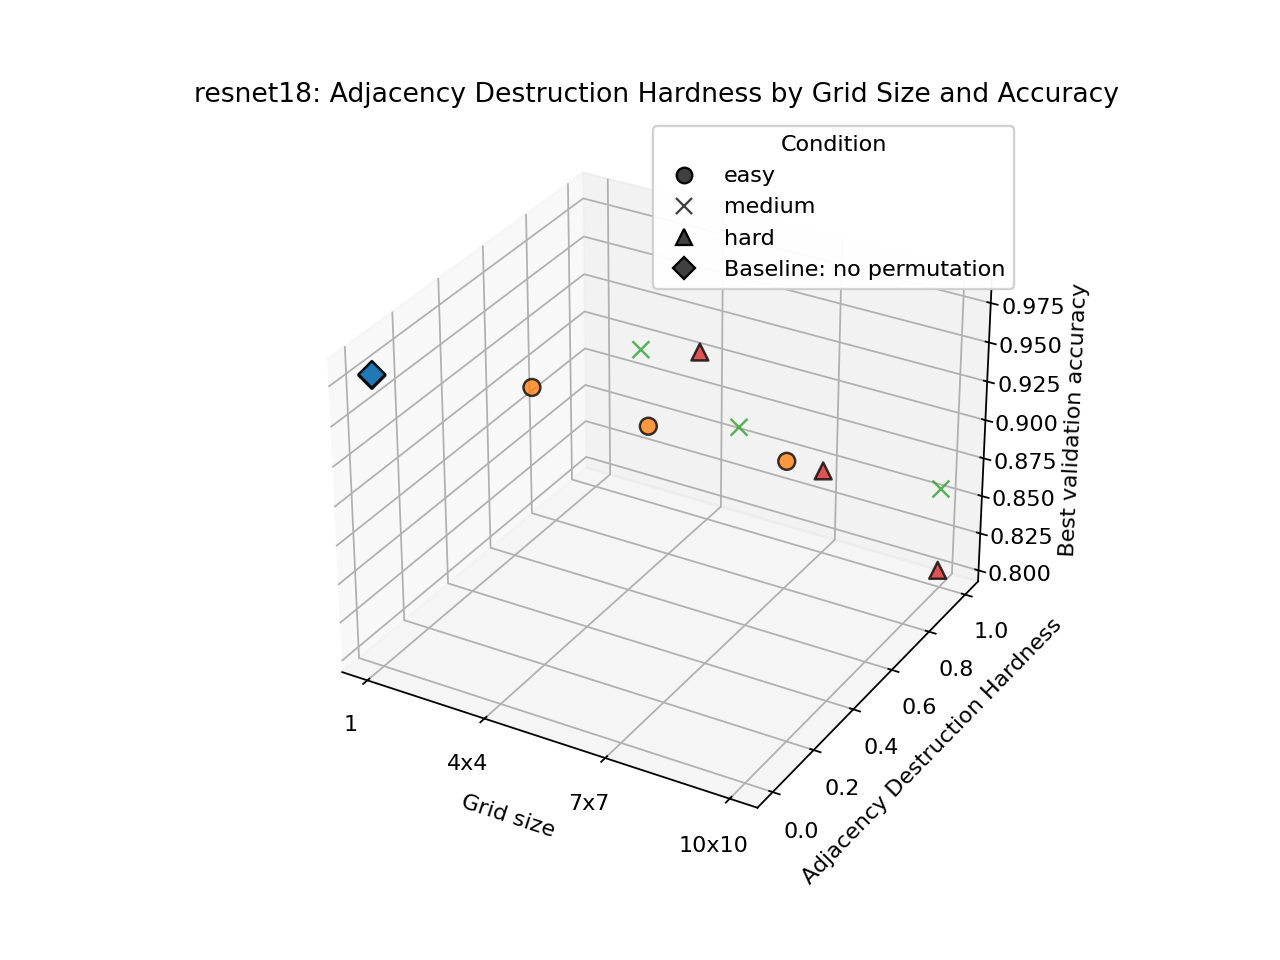

#### Part 3: Combined Hardness Grid Hardness Accuracy 3D

`outputs/figures/part3_combined_hardness_grid_hardness_accuracy_3d.png`

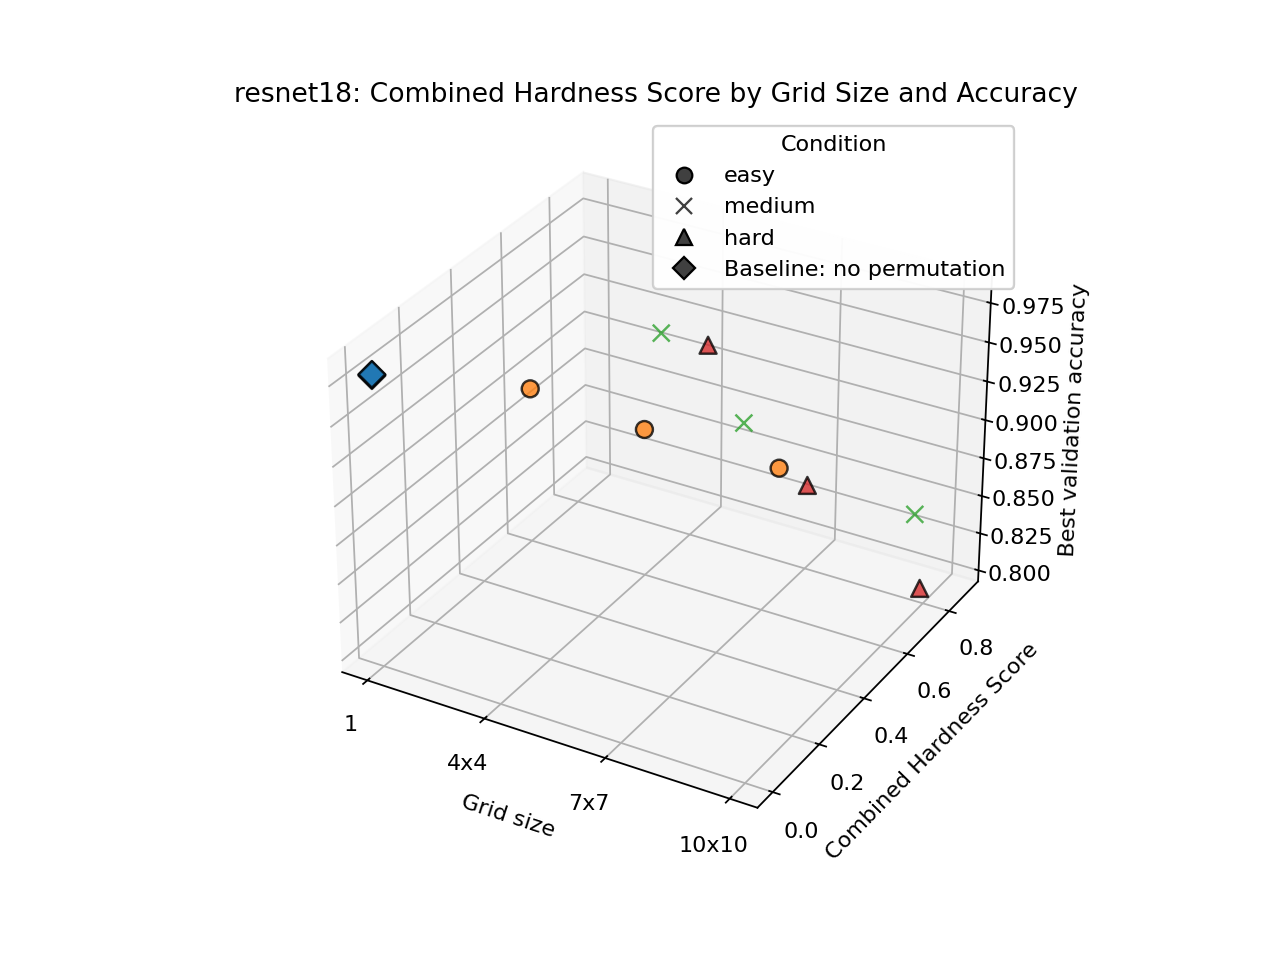

#### Part 3: Global Tile Displacement Grid Hardness Accuracy 3D

`outputs/figures/part3_global_tile_displacement_grid_hardness_accuracy_3d.png`

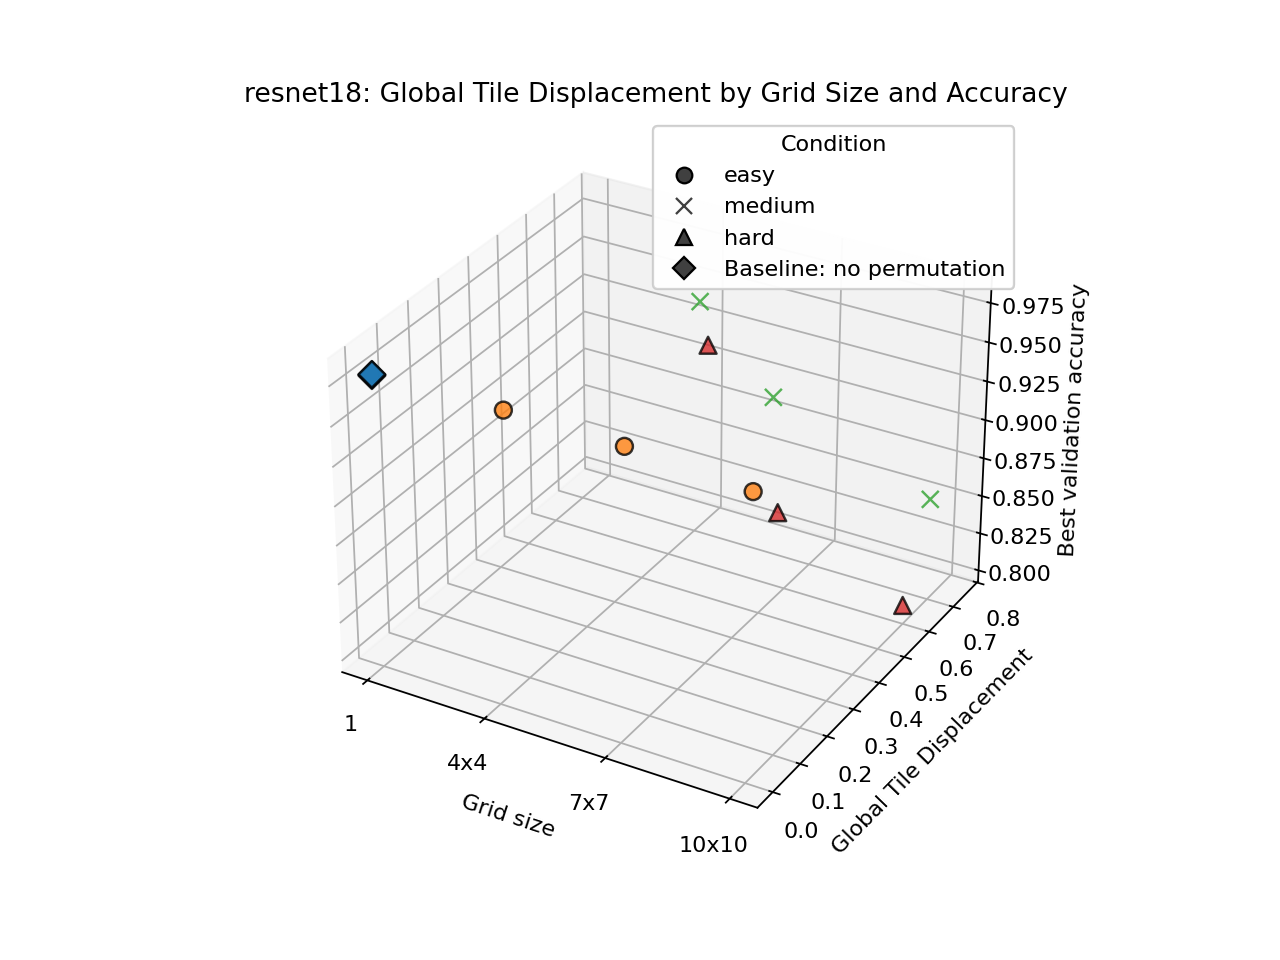

#### Part 3: Spatial Permutation Entropy Grid Hardness Accuracy 3D

`outputs/figures/part3_spatial_permutation_entropy_grid_hardness_accuracy_3d.png`

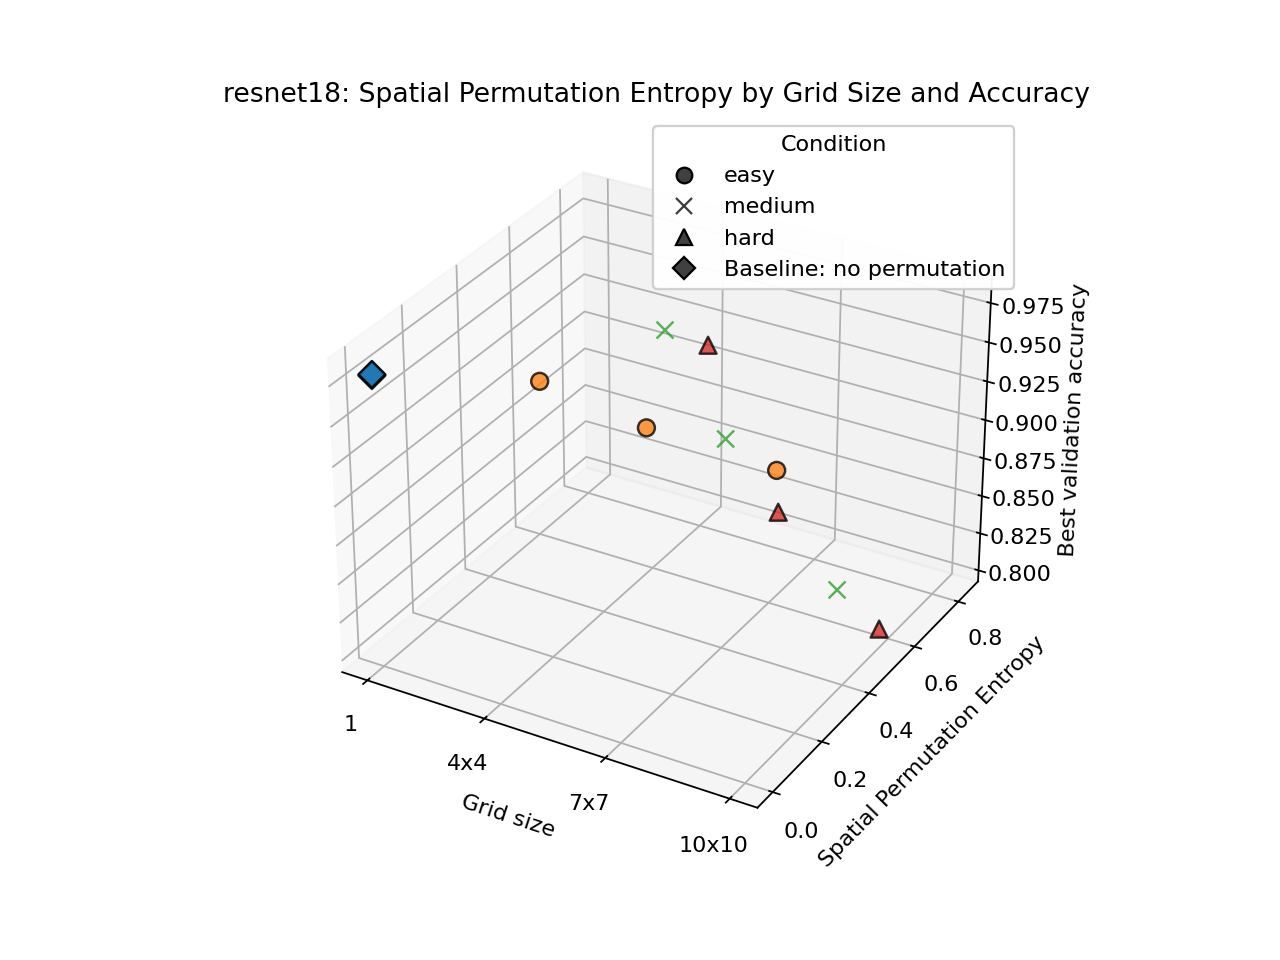

In [62]:
try:
    results_overview.ensure_part3_hardness_examples_figure(PROJECT_ROOT, force=True)
except Exception as error:
    print(f"Could not create Part 3 hardness examples plot: {error}")

results_overview.show_images(results_overview.part3_figures(FIGURES_DIR), project_root=PROJECT_ROOT)


## Finalize


In [63]:
# Export this saved notebook to PDF. Save the notebook before running this cell,
# because nbconvert reads the on-disk .ipynb file rather than unsaved editor state.
import importlib

import src.utils.notebook_setup as notebook_setup

notebook_setup = importlib.reload(notebook_setup)
notebook_path = PROJECT_ROOT / "src" / "notebooks" / "final_results_overview.ipynb"
export_dir = PROJECT_ROOT / "outputs" / "notebooks"
notebook_setup.export_notebook_to_pdf(notebook_path, export_dir)


Generated PDF: /Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/notebooks/final_results_overview.pdf


PosixPath('/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/notebooks/final_results_overview.pdf')